# Model Comparison Harness

The three project notebooks are not comparable as they stand — different targets, sample
sizes, feature filters, headline metrics, and each picks its own decision threshold. A
table built from their reported numbers would rank *leakage*, not model quality.

This notebook owns the whole pipeline so the **model** is the only thing that varies:

> one dataset → one target → one feature filter → one split → equal tuning budget → every model

**What is reused from the other notebooks**

| Source | Reused here |
|---|---|
| `XGBoost_v3` | Parquet loading, corrected feature filter, residual-leakage audit, leakage sweep, PR curve, searched hyperparameter space, model export |
| `DecisionTree` | Tree/forest configurations, decile lift, calibration curve, permutation importance, SHAP, confusion-matrix plots |
| `linear-regression-pipeline` | OLS-as-risk-score framing, Gini, KS statistic, decile lift table |

**What is new**

- Equal hyperparameter search budget for every model
- Paired bootstrap confidence intervals — same resampled rows for all models
- Shared operating points, so no model is judged at its own favourable threshold

## 1. Configuration

`QUICK = True` subsamples the data and shrinks the search so the notebook runs end to end
in a few minutes. Set it to `False` for the real run.

In [1]:
QUICK = False          # <-- set False for the full run

TARGET        = "bankruptcy"   # "bankruptcy" (0.65%) or "bad" (1.45%, the 3-event OR)
SEED          = 42
TEST_SIZE     = 0.20
CV_FOLDS      = 5

N_SEARCH_ITER = 5 if QUICK else 40      # candidates per model — identical for all
N_BOOTSTRAP   = 200 if QUICK else 1000
SUBSAMPLE     = 20_000 if QUICK else None
RUN_SWEEP     = not QUICK               # leakage sweep is slow
RUN_SHAP      = not QUICK

# Shared operating points — every model judged under the same constraint
TOP_K_FRAC    = 0.02    # "we can review the top 2% of customers"
TARGET_RECALL = 0.60    # "we need to catch 60% of bad customers"

REFERENCE_MODEL = "XGBoost"   # for paired difference tests

print(f"QUICK={QUICK}  target={TARGET}  search={N_SEARCH_ITER} candidates x {CV_FOLDS} folds")

QUICK=False  target=bankruptcy  search=40 candidates x 5 folds


In [2]:
import json, re, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (average_precision_score, roc_auc_score, roc_curve,
                             precision_recall_curve, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     RandomizedSearchCV, cross_val_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from scipy.stats import loguniform, randint, uniform

warnings.filterwarnings("ignore", category=FutureWarning)

rng_global = np.random.default_rng(SEED)
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

DATA_DIR = Path("../data")
OUT_DIR  = Path("../reports");  OUT_DIR.mkdir(exist_ok=True)
EXP_DIR  = Path("../exports");  EXP_DIR.mkdir(exist_ok=True)
print("ready")

ready


## 2. Load the 100k dataset

Parquet rather than Excel — under a second versus roughly 24 seconds, and 50MB versus
223MB. Generated by `scripts/convert_to_parquet.py`.

In [3]:
t0 = time.time()
df_raw = pd.read_parquet(DATA_DIR / "credit_risk_dataset_v2.parquet")
dd     = pd.read_parquet(DATA_DIR / "credit_risk_data_dictionary.parquet")

col2cat = dd.set_index("Column Name")["Category"].to_dict()
col2def = dd.set_index("Column Name")["Definition"].to_dict()
documented = set(dd["Column Name"])

print(f"loaded in {time.time()-t0:.1f}s   shape {df_raw.shape}")
print(f"data dictionary: {dd.shape[0]} attributes, {dd['Category'].nunique()} categories")

loaded in 0.1s   shape (100000, 538)
data dictionary: 537 attributes, 30 categories


## 3. Target definition

Two options, controlled by `TARGET`.

**`bankruptcy`** — a single event with one clear definition. Used by XGBoost v3.

**`bad`** — the original three-event OR from the group pipeline. Kept so the comparison can
be reproduced against the earlier notebooks, but note it is the harder label to defend:
three different events with different base rates collapsed into one flag.

In [4]:
BAD_SOURCE_COLS = ["risk_attribute_383060",   # worst status ever, all trades
                   "risk_attribute_274389",   # number of charge-off trades
                   "risk_attribute_272634"]   # number of public record bankruptcies

if TARGET == "bankruptcy":
    y_full = (df_raw["risk_attribute_272634"] > 0).astype(int)
    TARGET_DEF = "public record bankruptcies > 0"
else:
    y_full = ((df_raw["risk_attribute_383060"] >= 8)
              | (df_raw["risk_attribute_274389"] > 0)
              | (df_raw["risk_attribute_272634"] > 0)).astype(int)
    TARGET_DEF = "worst status >= 8 OR charge-off > 0 OR bankruptcy > 0"

print(f"target: {TARGET}  ({TARGET_DEF})")
print(y_full.value_counts().to_string())
print(f"base rate: {y_full.mean():.4f}")

for c in BAD_SOURCE_COLS:
    print(f"  {c} [{col2cat[c]}]: {col2def[c]}")

target: bankruptcy  (public record bankruptcies > 0)
risk_attribute_272634
0    99352
1      648
base rate: 0.0065
  risk_attribute_383060 [Worst Status Codes]: Worst status code ever on a all trades
  risk_attribute_274389 [Collections and Derogatory Metrics]: Total number of charge-off trades
  risk_attribute_272634 [Public Records and Bankruptcy]: Total number of public record bankruptcies


## 4. Feature filter

The strictest of the three notebooks. Four passes:

1. **Undocumented** — anything absent from the data dictionary (`customer_id`, and any
   derived column such as `bad`). Catching these structurally rather than by name means a
   new derived column cannot silently become a feature.
2. **Derogatory category** — 11 of 30 dictionary categories.
3. **Derogatory in definition** — regex over definition text. Category labels do not track
   content: *"Total dollar amount in derogatory status"* is filed under *Balance Metrics*.
4. **Scope-qualified** — "excluding derogatory" phrasings. Legitimate metrics, but
   differencing them against their unqualified twins recovers the derogatory amount.

The keyword list is the **union** of the terms used across all three notebooks, plus the
gaps found in review: `past due`, `worst`, `negative credit`, `deferred`, `dispute`,
`on-time`, `satisfactory`.

In [5]:
DEROGATORY_CATEGORIES = {
    "Delinquency Percentages", "Delinquency Counts – 30 Days",
    "Delinquency Counts – 60 Days and Severe", "Worst Status Codes",
    "Collections and Derogatory Metrics", "Months Since Delinquency",
    "Public Records and Bankruptcy", "Additional Delinquency Severity and Recurrence",
    "Derived and Composite Risk Indicators", "Financial Stress and Hardship Indicators",
    "Payment History and Behavior",
}

DEROG_TERMS = re.compile(
    r"delinq|derog|charge[ -]?off|charged[ -]?off|collection|bankrupt|public record|"
    r"dispute|repossess|foreclos|written[ -]?off|write[ -]?off|past[ -]?due|\bdpd\b|"
    r"worst|negative credit|deferred|deferment|forbearance|garnishment|judgment|lien|"
    r"settled|hardship|\bnsf\b|on[ -]?time|satisfactory|default|"
    r"ever 30|ever 60|ever 90|ever 120|30\+|60\+|90\+", re.I)

SCOPE = re.compile(r"\b(?:excluding|excl\.?|except|other than)\b[^,;.]*", re.I)

_txt     = dd["Definition"].fillna("") + " | " + dd["Valid Values / Notes"].fillna("")
_content = _txt.apply(lambda t: bool(DEROG_TERMS.search(SCOPE.sub(" ", t))))
_scope   = _txt.apply(lambda t: bool(DEROG_TERMS.search(t))) & ~_content
content_cols = set(dd.loc[_content, "Column Name"])
scope_cols   = set(dd.loc[_scope,   "Column Name"])

dropped = {"undocumented": [], "category": [], "definition": [], "scope": []}
clean_cols = []
for c in df_raw.columns:
    if c not in documented:                              dropped["undocumented"].append(c)
    elif col2cat.get(c) in DEROGATORY_CATEGORIES:        dropped["category"].append(c)
    elif c in content_cols:                              dropped["definition"].append(c)
    elif c in scope_cols:                                dropped["scope"].append(c)
    else:                                                clean_cols.append(c)

X_full = df_raw[clean_cols]

for k, v in dropped.items():
    print(f"dropped ({k}): {len(v)}" + (f"  -> {v}" if k == "undocumented" else ""))
print(f"\nfeatures kept: {X_full.shape[1]}")

for c in BAD_SOURCE_COLS:
    assert c not in X_full.columns, f"label source {c} leaked into features"
assert "bad" not in X_full.columns
print("assertions passed")

dropped (undocumented): 1  -> ['customer_id']
dropped (category): 229
dropped (definition): 61
dropped (scope): 47

features kept: 200
assertions passed


## 5. Residual leakage audit

Scored on **average precision, not ROC-AUC**. At a sub-1% base rate a feature can reach
ROC-AUC 0.95 while carrying almost no precision — thresholding on ROC-AUC produces false
alarms on ordinary credit-age features.

Reference points: AP ≈ base rate is random; 0.02–0.06 is an ordinary weak predictor;
above 0.25 warrants reading the definition; above 0.50 is almost certainly leakage.

In [6]:
floor_full = y_full.mean()
_rows = []
for c in X_full.columns:
    v = X_full[c].to_numpy()
    if np.unique(v).size < 2:
        continue
    ap = max(average_precision_score(y_full, v), average_precision_score(y_full, -v))
    a  = roc_auc_score(y_full, v)
    _rows.append({"feature": c, "avg_precision": ap, "lift": ap / floor_full,
                  "roc_auc": max(a, 1 - a)})

audit = (pd.DataFrame(_rows).sort_values("avg_precision", ascending=False)
         .set_index("feature"))
audit["category"]   = [col2cat.get(c) for c in audit.index]
audit["definition"] = [str(col2def.get(c))[:55] for c in audit.index]

print(f"random-guessing floor: {floor_full:.4f}\n")
print(audit.head(10).round(4).to_string())

BEST_FEATURE = audit.index[0]
worst_ap = audit["avg_precision"].iloc[0]
print(f"\nmax single-feature AP: {worst_ap:.4f}  ({worst_ap/floor_full:.1f}x floor)")
if worst_ap > 0.50:
    print("  -> LEAKING. Extend DEROG_TERMS and re-run.")
elif worst_ap > 0.25:
    print("  -> Suspiciously strong. Read the definitions above before trusting results.")
else:
    print("  -> No single column dominates. Reasonable to proceed.")
print(f"\nstrongest single feature (used as the 1-feature baseline): {BEST_FEATURE}")
print(f"  {col2def.get(BEST_FEATURE)}")

random-guessing floor: 0.0065

                       avg_precision     lift  roc_auc                                    category                                               definition
feature                                                                                                                                                    
risk_attribute_122056         0.0838  12.9262   0.9436                             Inquiry Metrics  Range of days between the first and last inquiry made i
risk_attribute_216970         0.0833  12.8540   0.9501               Credit Age and History Length  Average number of months since credit card trades were 
risk_attribute_103717         0.0799  12.3366   0.9436       Credit File Characteristics and Flags  Percentage of trades with balance-to-limit ratio above 
risk_attribute_716886         0.0799  12.3267   0.9425                             Inquiry Metrics  Average number of days between inquiries made in the la
risk_attribute_456699         0.0

## 6. Leakage sweep (optional)

Reproduces the diagnostic from XGBoost v3: drop features by descending single-feature AUC
and retrain at each threshold. Shows how deeply the label is recoverable from the *full*
attribute set — the reason the target had to be redefined in the first place.

Skipped when `QUICK` is on. Runs against the original `bad` label and all 534 features,
independent of the filtered set used below.

In [7]:
if RUN_SWEEP:
    from xgboost import XGBClassifier
    y_bad = ((df_raw["risk_attribute_383060"] >= 8)
             | (df_raw["risk_attribute_274389"] > 0)
             | (df_raw["risk_attribute_272634"] > 0)).astype(int)
    X_all = df_raw.drop(columns=["customer_id"] + BAD_SOURCE_COLS, errors="ignore")
    X_all = X_all[[c for c in X_all.columns if c in documented]]

    single = {}
    for c in X_all.columns:
        v = X_all[c].to_numpy()
        if np.unique(v).size < 2:
            continue
        a = roc_auc_score(y_bad, v)
        single[c] = max(a, 1 - a)
    single = pd.Series(single)
    spw_bad = (y_bad == 0).sum() / (y_bad == 1).sum()

    sweep = []
    for thr in [0.95, 0.90, 0.80, 0.70, 0.60]:
        drop = single[single > thr].index
        Xd = X_all.drop(columns=drop)
        a, b, c_, d = train_test_split(Xd, y_bad, test_size=0.2,
                                       random_state=SEED, stratify=y_bad)
        m = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                          subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
                          scale_pos_weight=spw_bad, eval_metric="aucpr",
                          random_state=SEED, n_jobs=-1).fit(a, c_)
        p = m.predict_proba(b)[:, 1]
        sweep.append({"drop_above_auc": thr, "n_dropped": len(drop), "n_left": Xd.shape[1],
                      "roc_auc": roc_auc_score(d, p),
                      "pr_auc": average_precision_score(d, p)})
    sweep_df = pd.DataFrame(sweep)
    print(sweep_df.round(4).to_string(index=False))
    print("\nThe label stays recoverable until most of the file is removed —")
    print("leakage is diffuse, which is why the target itself had to change.")
else:
    print("skipped (QUICK)")

 drop_above_auc  n_dropped  n_left  roc_auc  pr_auc
           0.95         19     515   1.0000  1.0000
           0.90        138     396   1.0000  1.0000
           0.80        318     216   0.9996  0.9943
           0.70        418     116   0.9864  0.6954
           0.60        475      59   0.8227  0.3661

The label stays recoverable until most of the file is removed —
leakage is diffuse, which is why the target itself had to change.


## 7. Split

One stratified split, fixed seed, used by every model. `SUBSAMPLE` thins the data in
`QUICK` mode while preserving the class balance.

In [8]:
if SUBSAMPLE and SUBSAMPLE < len(X_full):
    idx, _ = train_test_split(np.arange(len(X_full)), train_size=SUBSAMPLE,
                              random_state=SEED, stratify=y_full)
    X_use, y_use = X_full.iloc[idx], y_full.iloc[idx]
    print(f"subsampled to {len(X_use):,} rows (QUICK)")
else:
    X_use, y_use = X_full, y_full

X_train, X_test, y_train, y_test = train_test_split(
    X_use, y_use, test_size=TEST_SIZE, random_state=SEED, stratify=y_use)

y_test_np = y_test.to_numpy()
floor     = y_test_np.mean()
spw       = (y_train == 0).sum() / (y_train == 1).sum()

print(f"train {X_train.shape}   test {X_test.shape}")
print(f"train positives {int(y_train.sum())}   test positives {int(y_test.sum())}")
print(f"random-guessing floor on test: {floor:.4f}")
print(f"n_neg/n_pos (scale_pos_weight convention): {spw:.1f}")

train (80000, 200)   test (20000, 200)
train positives 518   test positives 130
random-guessing floor on test: 0.0065
n_neg/n_pos (scale_pos_weight convention): 153.4


## 8. The model zoo

Seven entries. Two are deliberate floors — if a model cannot beat them by more than the
bootstrap interval, its complexity is not earning anything.

| Model | Origin | Notes |
|---|---|---|
| Baseline (random) | — | `DummyClassifier`; the arithmetic floor |
| Logistic (1 feature) | — | Strongest single feature only; the interpretability floor |
| OLS risk score | linear-regression notebook | Wrapped so sklearn treats its output as a score |
| Logistic regression | — | Standard scorecard workhorse |
| Decision tree | DecisionTree notebook | |
| Random forest | DecisionTree notebook | |
| XGBoost | XGBoost v3 | |

**On the OLS wrapper.** `LinearRegression` has no `predict_proba` or `decision_function`,
so sklearn's `average_precision` scorer cannot use it directly. `OLSRiskScorer` exposes
`decision_function = predict`, which is exactly the linear notebook's framing: an
unbounded risk score valid for ranking, not a calibrated probability. It has no
hyperparameters, so the equal search budget does not apply to it — a property of OLS
rather than an unfairness in the comparison.

In [9]:
class OLSRiskScorer(ClassifierMixin, BaseEstimator):
    """OLS fit to a 0/1 target, exposed as a ranking score.

    Mirrors the linear-regression notebook: the output is a continuous risk score that
    may fall outside [0, 1]. Ranking metrics (AUC, KS, PR-AUC) are valid on it;
    calibration and log-loss are not.
    """
    # Mixin must precede BaseEstimator so sklearn tags this as a classifier;
    # otherwise scorers reject decision_function on a "regressor".
    _estimator_type = "classifier"

    def __init__(self, scale=True):
        self.scale = scale

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        steps = ([("scaler", StandardScaler())] if self.scale else []) + \
                [("ols", LinearRegression())]
        self.pipe_ = Pipeline(steps).fit(X, y)
        return self

    def decision_function(self, X):
        return self.pipe_.predict(X)

    def predict(self, X):
        return (self.decision_function(X) >= 0.5).astype(int)


single_sel = ColumnTransformer([("keep", "passthrough", [BEST_FEATURE])],
                               remainder="drop")

MODELS = {
    "Baseline (random)": DummyClassifier(strategy="stratified", random_state=SEED),

    "Logistic (1 feature)": Pipeline([
        ("select", single_sel),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced",
                                   random_state=SEED)),
    ]),

    "OLS risk score": OLSRiskScorer(),

    "Logistic regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced",
                                   random_state=SEED)),
    ]),

    "Decision tree": DecisionTreeClassifier(max_depth=5, class_weight="balanced",
                                            random_state=SEED),

    "Random forest": RandomForestClassifier(n_estimators=200, max_depth=8,
                                            class_weight="balanced",
                                            random_state=SEED, n_jobs=-1),
}

try:
    from xgboost import XGBClassifier
    MODELS["XGBoost"] = XGBClassifier(
        n_estimators=303, learning_rate=0.0146, max_depth=2, min_child_weight=29,
        reg_lambda=11.9453, reg_alpha=0.0161, gamma=0.0406,
        subsample=0.9913, colsample_bytree=0.4140, scale_pos_weight=5.9677,
        eval_metric="aucpr", tree_method="hist", random_state=SEED, n_jobs=-1)
except ImportError:
    print("xgboost not installed — skipping")

print(f"{len(MODELS)} models:")
for k in MODELS:
    print("  -", k)

7 models:
  - Baseline (random)
  - Logistic (1 feature)
  - OLS risk score
  - Logistic regression
  - Decision tree
  - Random forest
  - XGBoost


## 9. Equal tuning budget

Every tunable model gets **the same** `N_SEARCH_ITER` candidates, the same folds, and the
same scoring metric (`average_precision`). This removes the asymmetry in the original
notebooks, where XGBoost had a 100-candidate search behind it while the tree and forest
used hand-picked defaults.

Searches see **training data only**; the test set is scored once, at the end.

In [10]:
SEARCH_SPACES = {
    "Logistic regression": {
        "clf__C": loguniform(1e-3, 1e2),
        "clf__class_weight": [None, "balanced"],
    },
    "Decision tree": {
        "max_depth": randint(2, 12),
        "min_samples_leaf": randint(5, 100),
        "min_samples_split": randint(10, 200),
        "ccp_alpha": loguniform(1e-6, 1e-2),
        "class_weight": [None, "balanced"],
    },
    "Random forest": {
        "n_estimators": randint(100, 400),
        "max_depth": randint(3, 16),
        "min_samples_leaf": randint(1, 40),
        "max_features": uniform(0.1, 0.7),
        "class_weight": [None, "balanced", "balanced_subsample"],
    },
    "XGBoost": {
        "n_estimators": randint(150, 800),
        "learning_rate": loguniform(0.01, 0.2),
        "max_depth": randint(2, 7),
        "min_child_weight": randint(1, 30),
        "subsample": uniform(0.6, 0.4),
        "colsample_bytree": uniform(0.3, 0.7),
        "reg_lambda": loguniform(0.1, 50.0),
        "reg_alpha": loguniform(1e-3, 10.0),
        "gamma": loguniform(1e-4, 5.0),
        "scale_pos_weight": loguniform(1.0, spw * 2),
    },
}

fitted, best_params, cv_scores, timings = {}, {}, {}, {}

for name, est in MODELS.items():
    t0 = time.time()
    if name in SEARCH_SPACES:
        search = RandomizedSearchCV(
            clone(est), SEARCH_SPACES[name], n_iter=N_SEARCH_ITER,
            scoring="average_precision", cv=cv, n_jobs=-1,
            random_state=SEED, refit=True, error_score="raise")
        search.fit(X_train, y_train)
        fitted[name]      = search.best_estimator_
        best_params[name] = search.best_params_
        cv_scores[name]   = search.best_score_
        tag = f"CV PR-AUC {search.best_score_:.4f} (tuned, {N_SEARCH_ITER} candidates)"
    else:
        m = clone(est).fit(X_train, y_train)
        fitted[name]      = m
        best_params[name] = {}
        try:
            s = cross_val_score(clone(est), X_train, y_train, cv=cv,
                                scoring="average_precision", n_jobs=-1)
            cv_scores[name] = s.mean()
            tag = f"CV PR-AUC {s.mean():.4f} (no hyperparameters)"
        except Exception as e:
            cv_scores[name] = np.nan
            tag = f"CV n/a ({type(e).__name__})"
    timings[name] = time.time() - t0
    print(f"  {name:22s} {timings[name]:7.1f}s   {tag}")

  Baseline (random)          1.5s   CV PR-AUC 0.0065 (no hyperparameters)
  Logistic (1 feature)       1.3s   CV PR-AUC 0.0891 (no hyperparameters)
  OLS risk score            22.7s   CV PR-AUC 0.1007 (no hyperparameters)
  Logistic regression       40.4s   CV PR-AUC 0.1119 (tuned, 40 candidates)
  Decision tree             59.7s   CV PR-AUC 0.0843 (tuned, 40 candidates)
  Random forest           2787.6s   CV PR-AUC 0.1164 (tuned, 40 candidates)
  XGBoost                  280.2s   CV PR-AUC 0.1174 (tuned, 40 candidates)


## 10. Score on the shared test set

`decision_function` for the OLS score, `predict_proba` for everything else. All ranking
metrics below work identically on either.

In [11]:
def score_of(model, X):
    if hasattr(model, "predict_proba"):
        return np.asarray(model.predict_proba(X)[:, 1], dtype=float)
    return np.asarray(model.decision_function(X), dtype=float)

scores = {name: score_of(m, X_test) for name, m in fitted.items()}

for name, s in scores.items():
    print(f"  {name:22s} score range [{s.min():.4f}, {s.max():.4f}]")
print("\nNote the OLS range — it is a risk score, not a probability, and may fall")
print("outside [0, 1]. Ranking metrics remain valid; calibration does not apply.")

  Baseline (random)      score range [0.0000, 1.0000]
  Logistic (1 feature)   score range [0.0007, 0.9997]
  OLS risk score         score range [-0.0238, 0.1321]
  Logistic regression    score range [0.0000, 0.9986]
  Decision tree          score range [0.0000, 0.3068]
  Random forest          score range [0.0000, 0.9543]
  XGBoost                score range [0.0009, 0.9546]

Note the OLS range — it is a risk score, not a probability, and may fall
outside [0, 1]. Ranking metrics remain valid; calibration does not apply.


## 11. Headline metrics

**PR-AUC is the primary metric.** At this base rate ROC-AUC compresses every model into a
narrow band near 0.97 and hides real differences.

**Gini and KS** are carried alongside because they are the credit-domain conventions and
the linear-regression notebook computes them — but they are monotone transforms of AUC and
inherit its insensitivity here. A KS above roughly 0.60 on this task should prompt a
leakage check rather than celebration; production scorecards typically run 0.30–0.45.

In [12]:
def ks_stat(y_true, s):
    fpr, tpr, _ = roc_curve(y_true, s)
    return float(np.max(tpr - fpr))

rows = []
for name, s in scores.items():
    ap  = average_precision_score(y_test_np, s)
    auc = roc_auc_score(y_test_np, s)
    rows.append({"model": name, "cv_pr_auc": cv_scores.get(name, np.nan),
                 "pr_auc": ap, "lift": ap / floor, "roc_auc": auc,
                 "gini": 2 * auc - 1, "ks": ks_stat(y_test_np, s),
                 "fit_s": timings[name]})

metrics = pd.DataFrame(rows).sort_values("pr_auc", ascending=False).reset_index(drop=True)
print(f"random-guessing floor: {floor:.4f}\n")
print(metrics.round(4).to_string(index=False))

random-guessing floor: 0.0065

               model  cv_pr_auc  pr_auc    lift  roc_auc   gini     ks     fit_s
 Logistic regression     0.1119  0.1401 21.5575   0.9706 0.9411 0.8914   40.3996
             XGBoost     0.1174  0.1276 19.6235   0.9711 0.9422 0.8963  280.2357
       Random forest     0.1164  0.1131 17.3957   0.9685 0.9370 0.8953 2787.6499
      OLS risk score     0.1007  0.0968 14.8847   0.9523 0.9047 0.8337   22.7042
Logistic (1 feature)     0.0891  0.0875 13.4625   0.9387 0.8775 0.7769    1.3198
       Decision tree     0.0843  0.0763 11.7332   0.8807 0.7613 0.7649   59.6588
   Baseline (random)     0.0065  0.0072  1.1138   0.5122 0.0244 0.0244    1.4970


## 12. Paired bootstrap confidence intervals

A single point estimate on a few hundred test positives is not enough to rank models.

Each of `N_BOOTSTRAP` draws resamples the test rows with replacement and recomputes every
model's PR-AUC **on the same resampled rows**. Pairing controls for which customers landed
in the test set and is far more sensitive than comparing independent means.

In [13]:
def paired_bootstrap(y_true, score_dict, n_boot, seed=SEED):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    out = {m: np.empty(n_boot) for m in score_dict}
    for b in range(n_boot):
        idx = rng.integers(0, n, n)
        while y_true[idx].sum() == 0:
            idx = rng.integers(0, n, n)
        yb = y_true[idx]
        for m, s in score_dict.items():
            out[m][b] = average_precision_score(yb, s[idx])
    return out

t0 = time.time()
boots = paired_bootstrap(y_test_np, scores, N_BOOTSTRAP)
print(f"{N_BOOTSTRAP} paired resamples in {time.time()-t0:.1f}s\n")

ci = lambda a: (np.percentile(a, 2.5), np.percentile(a, 97.5))
metrics["pr_lo"], metrics["pr_hi"] = zip(*[ci(boots[m]) for m in metrics["model"]])
metrics["PR-AUC [95% CI]"] = metrics.apply(
    lambda r: f"{r.pr_auc:.4f} [{r.pr_lo:.4f}, {r.pr_hi:.4f}]", axis=1)

print(metrics[["model", "PR-AUC [95% CI]", "lift", "roc_auc", "gini", "ks"]]
      .round(4).to_string(index=False))

1000 paired resamples in 13.1s

               model         PR-AUC [95% CI]    lift  roc_auc   gini     ks
 Logistic regression 0.1401 [0.1083, 0.1958] 21.5575   0.9706 0.9411 0.8914
             XGBoost 0.1276 [0.1004, 0.1684] 19.6235   0.9711 0.9422 0.8963
       Random forest 0.1131 [0.0900, 0.1489] 17.3957   0.9685 0.9370 0.8953
      OLS risk score 0.0968 [0.0730, 0.1354] 14.8847   0.9523 0.9047 0.8337
Logistic (1 feature) 0.0875 [0.0584, 0.1317] 13.4625   0.9387 0.8775 0.7769
       Decision tree 0.0763 [0.0568, 0.1054] 11.7332   0.8807 0.7613 0.7649
   Baseline (random) 0.0072 [0.0058, 0.0101]  1.1138   0.5122 0.0244 0.0244


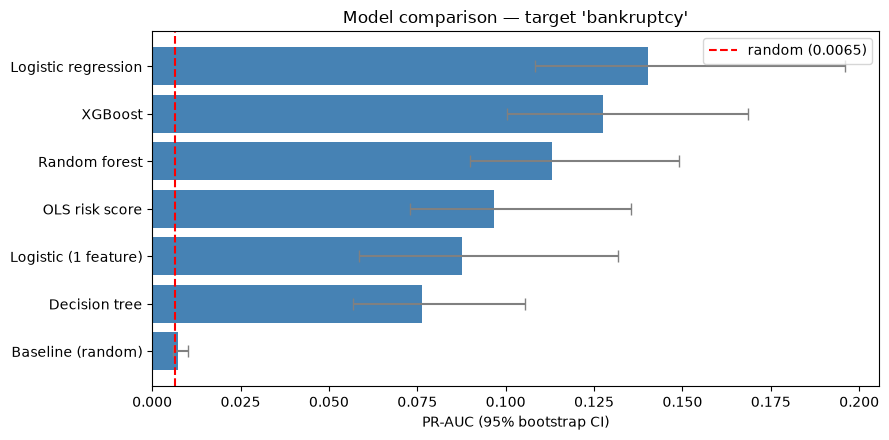

In [14]:
fig, ax = plt.subplots(figsize=(9, 4.5))
order = metrics.sort_values("pr_auc")
ax.barh(order["model"], order["pr_auc"],
        xerr=[order["pr_auc"] - order["pr_lo"], order["pr_hi"] - order["pr_auc"]],
        color="steelblue", ecolor="grey", capsize=4)
ax.axvline(floor, ls="--", c="red", label=f"random ({floor:.4f})")
ax.set_xlabel("PR-AUC (95% bootstrap CI)")
ax.set_title(f"Model comparison — target '{TARGET}'")
ax.legend()
plt.tight_layout(); plt.show()

## 13. Paired differences

The ranking above is only meaningful where the intervals separate. This tests each model
against a reference on the **same** resampled rows. A CI excluding zero means the
difference exceeds sampling noise; a CI straddling zero means the two are
indistinguishable, however different their point estimates look.

In [15]:
ref = REFERENCE_MODEL if REFERENCE_MODEL in scores else metrics.iloc[0]["model"]

diffs = []
for name in scores:
    if name == ref:
        continue
    d = boots[ref] - boots[name]
    lo, hi = ci(d)
    diffs.append({"reference": ref, "model": name, "mean_diff": d.mean(),
                  "ci_lo": lo, "ci_hi": hi, "distinguishable": bool(lo > 0 or hi < 0)})

pairwise = pd.DataFrame(diffs).sort_values("mean_diff", ascending=False)
print(f"paired difference vs {ref}\n")
print(pairwise.round(4).to_string(index=False))

n_sig = int(pairwise["distinguishable"].sum())
print(f"\n{n_sig} of {len(pairwise)} differences exceed sampling noise.")
if n_sig == 0:
    print("No model separates from the reference. That is a legitimate finding, and it")
    print("argues for the simplest model on interpretability grounds.")

paired difference vs XGBoost

reference                model  mean_diff   ci_lo  ci_hi  distinguishable
  XGBoost    Baseline (random)     0.1242  0.0932 0.1603             True
  XGBoost        Decision tree     0.0535  0.0228 0.0868             True
  XGBoost Logistic (1 feature)     0.0403  0.0045 0.0766             True
  XGBoost       OLS risk score     0.0309 -0.0007 0.0604            False
  XGBoost        Random forest     0.0149 -0.0048 0.0369            False
  XGBoost  Logistic regression    -0.0149 -0.0480 0.0127            False

3 of 6 differences exceed sampling noise.


## 14. Shared operating points

Each source notebook picked its own threshold — 0.5, then 0.7, then KS-optimal, then
max-F1. Those are not comparable.

Here every model is judged under the **same two constraints**:

- **Capacity** — we can review the top `TOP_K_FRAC` of customers. What precision do we get?
- **Coverage** — we must catch `TARGET_RECALL` of bad customers. How many must we flag?

The second is usually the number a lender actually asks for.

In [16]:
def precision_at_top_k(y_true, s, k_frac):
    n = max(1, int(round(len(s) * k_frac)))
    idx = np.argsort(-s)[:n]
    return float(y_true[idx].mean()), n, int(y_true[idx].sum())

def precision_at_recall(y_true, s, target_recall):
    order = np.argsort(-s)
    y_sorted = y_true[order]
    tp = np.cumsum(y_sorted)
    rec = tp / y_true.sum()
    hit = int(np.searchsorted(rec, target_recall, side="left"))
    if hit >= len(rec):
        return float("nan"), len(rec)
    return float(tp[hit] / (hit + 1)), hit + 1

ops = []
for name, s in scores.items():
    p_k, n_k, caught = precision_at_top_k(y_test_np, s, TOP_K_FRAC)
    p_r, n_r = precision_at_recall(y_test_np, s, TARGET_RECALL)
    ops.append({
        "model": name,
        f"precision@top{TOP_K_FRAC:.0%}": p_k,
        f"caught_of_{int(y_test.sum())}": caught,
        f"precision@recall{TARGET_RECALL:.0%}": p_r,
        f"flagged@recall{TARGET_RECALL:.0%}": n_r,
    })

operating = pd.DataFrame(ops).sort_values(f"precision@top{TOP_K_FRAC:.0%}",
                                          ascending=False)
n_review = int(len(y_test_np) * TOP_K_FRAC)
print(f"Test set: {len(y_test_np):,} customers, {int(y_test.sum())} bad.")
print(f"Reviewing the top {TOP_K_FRAC:.0%} means {n_review} files.\n")
print(operating.round(4).to_string(index=False))

Test set: 20,000 customers, 130 bad.
Reviewing the top 2% means 400 files.

               model  precision@top2%  caught_of_130  precision@recall60%  flagged@recall60%
             XGBoost           0.1450             58               0.1300                600
 Logistic regression           0.1425             57               0.1209                645
       Random forest           0.1225             49               0.1240                629
      OLS risk score           0.1050             42               0.0709               1100
       Decision tree           0.0850             34               0.0796                980
Logistic (1 feature)           0.0800             32               0.0644               1212
   Baseline (random)           0.0150              6               0.0066              11746


## 15. PR curves

The shape matters as much as the area. A curve with precision pinned near 1.0 out to
substantial recall is a leakage signature, not a good model — that is what the original
XGBoost baseline produced before the target was redefined.

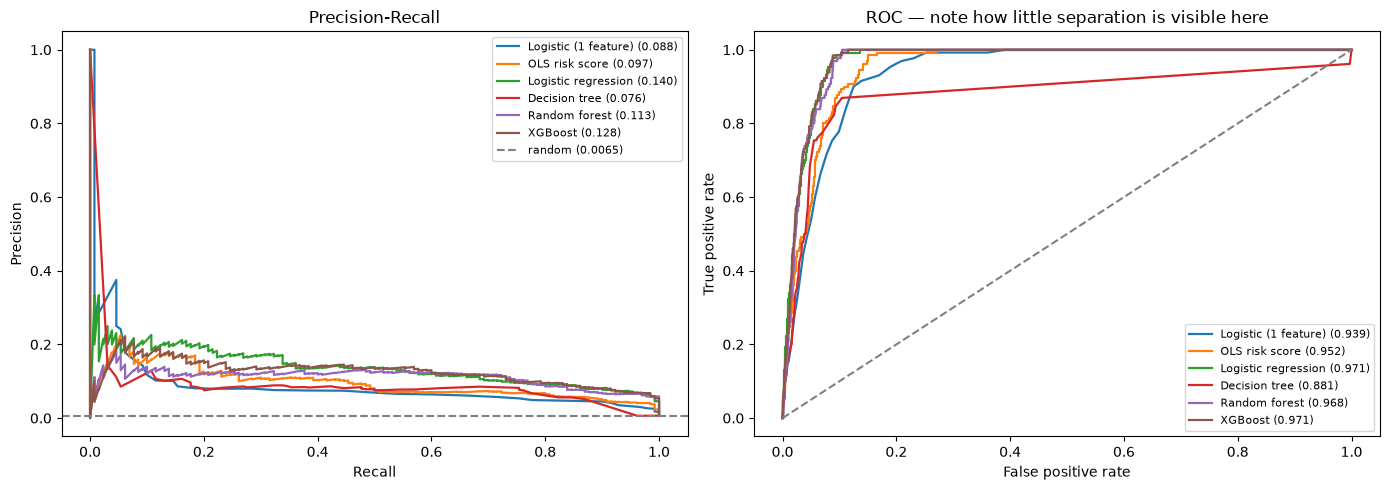

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, s in scores.items():
    if name == "Baseline (random)":
        continue
    prec, rec, _ = precision_recall_curve(y_test_np, s)
    axes[0].plot(rec, prec, lw=1.6,
                 label=f"{name} ({average_precision_score(y_test_np, s):.3f})")
axes[0].axhline(floor, ls="--", c="grey", label=f"random ({floor:.4f})")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall"); axes[0].legend(fontsize=8)

for name, s in scores.items():
    if name == "Baseline (random)":
        continue
    fpr, tpr, _ = roc_curve(y_test_np, s)
    axes[1].plot(fpr, tpr, lw=1.6,
                 label=f"{name} ({roc_auc_score(y_test_np, s):.3f})")
axes[1].plot([0, 1], [0, 1], "--", c="grey")
axes[1].set_xlabel("False positive rate"); axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC — note how little separation is visible here")
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

## 16. Decile lift

From the linear-regression and Decision Tree notebooks. Customers are sorted into ten
score bands; decile 10 is the highest risk. A working model concentrates bad customers in
the top deciles with a **gradient** across the rest.

A step function — everything in decile 10, zeros below — indicates leakage rather than
skill.

In [18]:
lift_tables = {}
for name, s in scores.items():
    if name == "Baseline (random)":
        continue
    d = pd.DataFrame({"score": s, "bad": y_test_np})
    d["decile"] = pd.qcut(d["score"].rank(method="first"), 10, labels=False) + 1
    t = (d.groupby("decile")
           .agg(n=("bad", "size"), bads=("bad", "sum"), bad_rate=("bad", "mean"))
           .sort_index(ascending=False))
    t["cum_pct_bads"] = t["bads"].cumsum() / t["bads"].sum()
    t["lift"] = t["bad_rate"] / floor
    lift_tables[name] = t

top_model = metrics.iloc[0]["model"]
print(f"Decile lift — {top_model}\n")
print(lift_tables[top_model].round(4).to_string())

print("\n\nTop-decile capture, all models:")
cap = pd.DataFrame([
    {"model": n, "top_decile_bad_rate": t.loc[10, "bad_rate"],
     "top_decile_lift": t.loc[10, "lift"],
     "pct_bads_in_top_decile": t.loc[10, "cum_pct_bads"]}
    for n, t in lift_tables.items()
]).sort_values("pct_bads_in_top_decile", ascending=False)
print(cap.round(4).to_string(index=False))

Decile lift — Logistic regression

           n  bads  bad_rate  cum_pct_bads    lift
decile                                            
10      2000   128     0.064        0.9846  9.8462
9       2000     2     0.001        1.0000  0.1538
8       2000     0     0.000        1.0000  0.0000
7       2000     0     0.000        1.0000  0.0000
6       2000     0     0.000        1.0000  0.0000
5       2000     0     0.000        1.0000  0.0000
4       2000     0     0.000        1.0000  0.0000
3       2000     0     0.000        1.0000  0.0000
2       2000     0     0.000        1.0000  0.0000
1       2000     0     0.000        1.0000  0.0000


Top-decile capture, all models:
               model  top_decile_bad_rate  top_decile_lift  pct_bads_in_top_decile
             XGBoost               0.0640           9.8462                  0.9846
 Logistic regression               0.0640           9.8462                  0.9846
       Random forest               0.0630           9.6923            

## 17. Calibration

From the Decision Tree notebook. Asks whether a predicted 30% actually corresponds to a
30% observed rate — i.e. whether the output is usable as a risk *estimate* rather than
just a ranking.

**Only applies to probability models.** The OLS score is unbounded and the dummy baseline
is degenerate, so both are excluded. Note also that `class_weight="balanced"` and
`scale_pos_weight` deliberately distort probabilities toward the minority class, so
well-ranked models routinely calibrate poorly here. That is a known trade-off, not a bug.

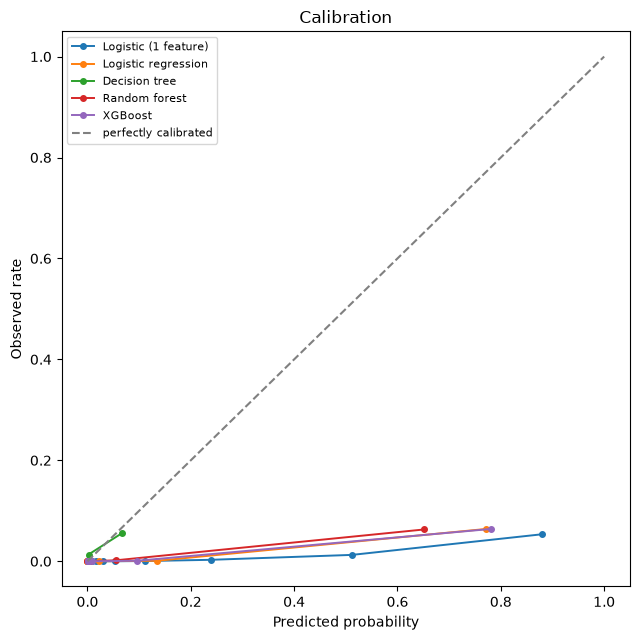

5 probability models plotted; OLS excluded (unbounded score).


In [19]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
plotted = 0
for name, m in fitted.items():
    if name == "Baseline (random)" or not hasattr(m, "predict_proba"):
        continue
    s = scores[name]
    try:
        prob_true, prob_pred = calibration_curve(y_test_np, s, n_bins=10,
                                                 strategy="quantile")
        ax.plot(prob_pred, prob_true, marker="o", ms=4, lw=1.4, label=name)
        plotted += 1
    except Exception as e:
        print(f"  {name}: {type(e).__name__}")

ax.plot([0, 1], [0, 1], "--", c="grey", label="perfectly calibrated")
ax.set_xlabel("Predicted probability"); ax.set_ylabel("Observed rate")
ax.set_title("Calibration"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"{plotted} probability models plotted; OLS excluded (unbounded score).")

## 18. Confusion matrices at the shared operating point

Every model cut at **its own threshold for `TARGET_RECALL`**, so the recall row is held
constant and the comparison is purely about how many false positives each incurs to get
there. This is the fair version of the confusion-matrix comparison in the Decision Tree
notebook, which used each model's default 0.5 cutoff.

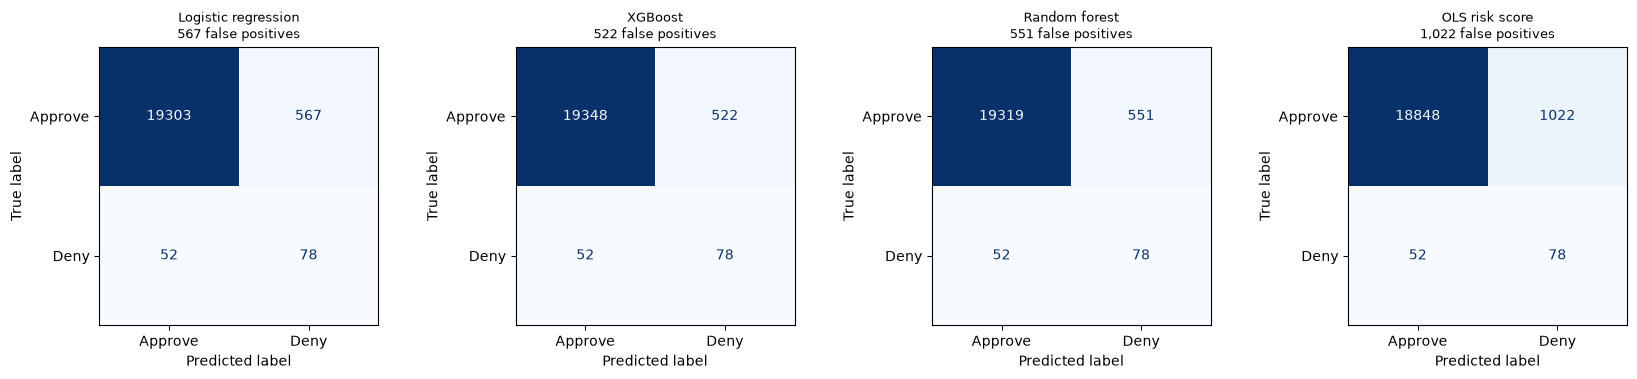

All cut at ~60% recall. Fewer false positives is better.
  Logistic regression    threshold   0.9364   FP    567   TP   78
  XGBoost                threshold   0.9143   FP    522   TP   78
  Random forest          threshold   0.8817   FP    551   TP   78
  OLS risk score         threshold   0.0352   FP  1,022   TP   78


In [20]:
def threshold_for_recall(y_true, s, target_recall):
    order = np.argsort(-s)
    tp = np.cumsum(y_true[order])
    rec = tp / y_true.sum()
    hit = int(np.searchsorted(rec, target_recall, side="left"))
    hit = min(hit, len(s) - 1)
    return s[order][hit]

show = [m for m in metrics["model"] if m != "Baseline (random)"][:4]
fig, axes = plt.subplots(1, len(show), figsize=(4.2 * len(show), 3.8))
if len(show) == 1:
    axes = [axes]

for ax, name in zip(axes, show):
    s = scores[name]
    thr = threshold_for_recall(y_test_np, s, TARGET_RECALL)
    pred = (s >= thr).astype(int)
    cm = confusion_matrix(y_test_np, pred)
    ConfusionMatrixDisplay(cm, display_labels=["Approve", "Deny"]).plot(
        ax=ax, cmap="Blues", values_format="d", colorbar=False)
    fp = cm[0, 1]
    ax.set_title(f"{name}\n{fp:,} false positives", fontsize=9)
plt.tight_layout(); plt.show()

print(f"All cut at ~{TARGET_RECALL:.0%} recall. Fewer false positives is better.")
for name in show:
    s = scores[name]
    thr = threshold_for_recall(y_test_np, s, TARGET_RECALL)
    cm = confusion_matrix(y_test_np, (s >= thr).astype(int))
    print(f"  {name:22s} threshold {thr:8.4f}   FP {cm[0,1]:6,}   TP {cm[1,1]:4,}")

## 19. What each model relies on

Coefficients for the linear models (standardized, so magnitudes compare), gain for the
tree models. Reading these against the data dictionary is the check that no derogatory
attribute survived the filter.

In [21]:
def importance_of(name, model):
    if name == "OLS risk score":
        return pd.Series(model.pipe_.named_steps["ols"].coef_, index=X_train.columns)
    if isinstance(model, Pipeline) and "clf" in model.named_steps:
        clf = model.named_steps["clf"]
        if hasattr(clf, "coef_"):
            cols = ([BEST_FEATURE] if "select" in model.named_steps
                    else list(X_train.columns))
            return pd.Series(clf.coef_[0], index=cols)
    if hasattr(model, "feature_importances_"):
        return pd.Series(model.feature_importances_, index=X_train.columns)
    return None

for name in [m for m in metrics["model"] if m != "Baseline (random)"][:3]:
    imp = importance_of(name, fitted[name])
    if imp is None:
        continue
    top = imp.reindex(imp.abs().sort_values(ascending=False).index).head(8)
    print(f"\n=== {name} ===")
    out = pd.DataFrame({
        "value": top.round(4),
        "category": [col2cat.get(c) for c in top.index],
        "definition": [str(col2def.get(c))[:58] for c in top.index],
    })
    print(out.to_string())


=== Logistic regression ===
                        value                                    category                                                  definition
risk_attribute_216970 -0.2227               Credit Age and History Length  Average number of months since credit card trades were ope
risk_attribute_654816  0.2159                             Balance Metrics  Maximum balance on open first mortgage trades reported in 
risk_attribute_122056  0.1798                             Inquiry Metrics  Range of days between the first and last inquiry made in t
risk_attribute_704201  0.1682                 Auto Loan and Lease Metrics  Total balance on open auto loan trades reported in the las
risk_attribute_776856 -0.1626  Installment, Revolving, and Retail Metrics  Number of months since most recently opened retail store c
risk_attribute_765095  0.1596       Credit File Characteristics and Flags  Total number of trades opened and closed within same 12-mo
risk_attribute_595631  0.1587    

## 20. Permutation importance

From the Decision Tree notebook, with two changes: scored on `average_precision` rather
than ROC-AUC, and run on the best model only (it refits nothing but is O(features x
repeats), so it is slow on 200+ columns).

More trustworthy than built-in importances, which are biased toward high-cardinality
features.

In [22]:
best_name  = metrics.iloc[0]["model"]
best_model = fitted[best_name]

n_rep = 3 if QUICK else 10
t0 = time.time()
perm = permutation_importance(best_model, X_test, y_test, n_repeats=n_rep,
                              random_state=SEED, scoring="average_precision", n_jobs=-1)
print(f"{best_name}: {n_rep} repeats in {time.time()-t0:.0f}s\n")

pi = (pd.DataFrame({"drop_in_pr_auc": perm.importances_mean,
                    "std": perm.importances_std}, index=X_test.columns)
      .sort_values("drop_in_pr_auc", ascending=False).head(15))
pi["category"]   = [col2cat.get(c) for c in pi.index]
pi["definition"] = [str(col2def.get(c))[:55] for c in pi.index]
print(pi.round(4).to_string())

Logistic regression: 10 repeats in 12s

                       drop_in_pr_auc     std                                    category                                               definition
risk_attribute_654816          0.0061  0.0052                             Balance Metrics  Maximum balance on open first mortgage trades reported 
risk_attribute_216970          0.0058  0.0041               Credit Age and History Length  Average number of months since credit card trades were 
risk_attribute_761759          0.0026  0.0013                   Mortgage-Specific Metrics  Total balance on open FHA first mortgage trades reporte
risk_attribute_378082          0.0025  0.0022          Personal Finance and Student Loans  Number of months since the most recently opened student
risk_attribute_736059          0.0023  0.0016        Trade Counts – Open and Newly Opened  Total number of trades where payment behavior in most r
risk_attribute_765095          0.0022  0.0035       Credit File Characteristic

In [23]:
if RUN_SHAP:
    try:
        import shap
        expl = shap.TreeExplainer(best_model)
        samp = X_test.sample(min(2000, len(X_test)), random_state=SEED)
        sv = expl.shap_values(samp)
        if isinstance(sv, list):
            sv = sv[1]
        shap.summary_plot(sv, samp, max_display=15)
    except ImportError:
        print("shap not installed:  pip install shap")
    except Exception as e:
        print(f"SHAP unavailable for {best_name}: {type(e).__name__} — "
              "TreeExplainer only supports tree models.")
else:
    print("skipped (QUICK)")

shap not installed:  pip install shap


## 21. Export the winner

In [24]:
import joblib, platform, sklearn
from datetime import datetime, timezone

thr = threshold_for_recall(y_test_np, scores[best_name], TARGET_RECALL)
tag = best_name.lower().replace(" ", "_").replace("(", "").replace(")", "")
model_path = EXP_DIR / f"harness_{tag}.joblib"
joblib.dump(best_model, model_path)

meta = {
    "model": best_name,
    "created_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "target": {"name": TARGET, "definition": TARGET_DEF,
               "positive_rate": float(y_use.mean())},
    "feature_names": list(X_train.columns),
    "n_features": int(X_train.shape[1]),
    "decision_threshold": float(thr),
    "threshold_basis": f"{TARGET_RECALL:.0%} recall on held-out test set",
    "metrics_heldout": {
        "pr_auc": float(metrics.iloc[0]["pr_auc"]),
        "pr_auc_ci": [float(metrics.iloc[0]["pr_lo"]), float(metrics.iloc[0]["pr_hi"])],
        "roc_auc": float(metrics.iloc[0]["roc_auc"]),
        "gini": float(metrics.iloc[0]["gini"]),
        "ks": float(metrics.iloc[0]["ks"]),
        "random_floor": float(floor),
    },
    "best_params": {k: (v.item() if hasattr(v, "item") else v)
                    for k, v in best_params.get(best_name, {}).items()},
    "search_budget": N_SEARCH_ITER,
    "seed": SEED,
    "environment": {"scikit_learn": sklearn.__version__,
                    "python": platform.python_version()},
    "limitations": [
        "Synthetic label derived from a contemporaneous bureau snapshot, not an "
        "observed forward-looking default.",
        "No time separation between features and label; some features reflect the "
        "aftermath of the event rather than predicting it.",
        "Not suitable for credit decisions. Coursework artifact.",
    ],
}
(EXP_DIR / f"harness_{tag}_metadata.json").write_text(json.dumps(meta, indent=2))

metrics.to_csv(OUT_DIR / "comparison_metrics.csv", index=False)
operating.to_csv(OUT_DIR / "comparison_operating.csv", index=False)
pairwise.to_csv(OUT_DIR / "comparison_pairwise.csv", index=False)

print(f"model    -> {model_path}")
print(f"metadata -> harness_{tag}_metadata.json")
print(f"tables   -> {OUT_DIR}/comparison_*.csv")

model    -> ..\exports\harness_logistic_regression.joblib
metadata -> harness_logistic_regression_metadata.json
tables   -> ..\reports/comparison_*.csv


## 22. Summary

In [25]:
print("=" * 72)
print(f"MODEL COMPARISON — target '{TARGET}' ({TARGET_DEF})")
print("=" * 72)
print(f"rows {len(X_use):,} | features {X_train.shape[1]} | "
      f"test positives {int(y_test.sum())} | floor {floor:.4f}")
print(f"search budget: {N_SEARCH_ITER} candidates x {CV_FOLDS} folds, "
      f"identical for every tunable model")
print(f"max single-feature AP after filtering: {worst_ap:.4f}\n")

print(metrics[["model", "PR-AUC [95% CI]", "lift", "ks"]].round(4).to_string(index=False))

print(f"\nBest: {best_name}")
print(f"  {int(y_test.sum() * TARGET_RECALL)} of {int(y_test.sum())} bad customers "
      f"caught by flagging "
      f"{operating.set_index('model').loc[best_name, f'flagged@recall{TARGET_RECALL:.0%}']:,} "
      f"of {len(y_test_np):,}")

print(f"\nDifferences vs {ref} exceeding noise: "
      f"{int(pairwise['distinguishable'].sum())} of {len(pairwise)}")
if int(pairwise["distinguishable"].sum()) == 0:
    print("  -> No model separates. Prefer the simplest on interpretability grounds.")

if QUICK:
    print("\n*** QUICK MODE — subsampled data and a small search. "
          "Set QUICK = False for the reportable run. ***")

MODEL COMPARISON — target 'bankruptcy' (public record bankruptcies > 0)
rows 100,000 | features 200 | test positives 130 | floor 0.0065
search budget: 40 candidates x 5 folds, identical for every tunable model
max single-feature AP after filtering: 0.0838

               model         PR-AUC [95% CI]    lift     ks
 Logistic regression 0.1401 [0.1083, 0.1958] 21.5575 0.8914
             XGBoost 0.1276 [0.1004, 0.1684] 19.6235 0.8963
       Random forest 0.1131 [0.0900, 0.1489] 17.3957 0.8953
      OLS risk score 0.0968 [0.0730, 0.1354] 14.8847 0.8337
Logistic (1 feature) 0.0875 [0.0584, 0.1317] 13.4625 0.7769
       Decision tree 0.0763 [0.0568, 0.1054] 11.7332 0.7649
   Baseline (random) 0.0072 [0.0058, 0.0101]  1.1138 0.0244

Best: Logistic regression
  78 of 130 bad customers caught by flagging 645 of 20,000

Differences vs XGBoost exceeding noise: 3 of 6


### Reading the result

**PR-AUC against the floor is the headline.** Accuracy and ROC-AUC both look excellent for
any model on a sub-1% event and neither distinguishes them.

**Where confidence intervals overlap, do not rank.** "Statistically indistinguishable" is
a finding, and it favours the simpler model — which for a credit scorecard is a real
advantage, not a consolation prize.

**Check the decile table and PR curve shape** before believing any strong result. A step
function or precision pinned near 1.0 means leakage survived the filter.

**Every number here rests on a synthetic label** built from a contemporaneous snapshot.
The comparison between models is sound; the absolute values describe this constructed task,
not real-world bankruptcy prediction.